# 07_3. 장애인콜택시 의료 목적지 × 진료과목별 규모지표 분석

`07_2_medical_destination_analysis_and_insights.ipynb`의 산출물(의사수_총합 등)을 이어받아,
`260907_07_3_진료과목_규모지표분석_계획.md`(v6, 확정)에서 정리한 진료과목 지표 분석을 담는다.

## 07_3의 목적

> 07_3의 목적은 **특정 진료과목이 장애인콜택시 이용을 설명한다는 것을 증명하는 것이 아니라**, 기존 의료서비스 규모 지표(병원 수·병상 수·의사 수)에
> 진료과목별 기관 분포 및 전문의 수를 추가했을 때 목적지 지역의 장애인콜택시 이용 패턴이 어떻게 달라지는지 **탐색**하고, 후속 분석이 필요한
> 지역·지표를 식별하는 것이다.

"확인된 사실 → 탐색적 관계 → 가설 → 인과관계 주장 불가"라는 프로젝트 공통 원칙을 그대로 따른다.

## 분석 질문 (Q1~Q5, Q2')

| 질문 | 내용 |
|---|---|
| Q1 | 병원 수 → 병상 수 → 의사 수 → 진료과목 지표 중 어떤 지표가 목적지 콜건수와 더 강한 탐색적 관계를 보이는가? |
| Q2 | 재활의학과의 보유기관수·전문의수는 기존 의사수 지표와 유사한 지역 패턴을 보이는가? |
| Q2' | 재활의학과 관계는 5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소) 중 특정 종별이 주도하는가, 종별 전반에 고르게 나타나는가? |
| Q3 | 다른 장애유형별 분석 후보 진료과목에서도 유사한 패턴이 재현되는가? |
| Q4 | 의료기관의 단순 총량과 종별/진료과목 구성 중 어느 쪽에서 더 뚜렷한 지역 차이가 관찰되는가? |
| Q5 | 의료서비스 규모와 콜택시 목적지 규모를 기준으로 어떤 지역 유형이 나타나는가? |

## 장애유형별 분석 후보 진료과목 매핑

근거는 이 프로젝트의 실제 장애유형 데이터(`서울시설공단_장애인콜택시 장애종류_20250528.csv`, 15종)다.

| 장애유형 | 분석 후보 진료과목 |
|---|---|
| 지체장애 | 정형외과, 재활의학과 |
| 뇌병변장애 | 신경과, 재활의학과, 신경외과 |
| 시각장애 | 안과 |
| 청각장애 | 이비인후과 |
| 지적장애 / 자폐성장애 | 정신건강의학과, 소아청소년과 |
| 정신장애 | 정신건강의학과 |
| 신장·심장·호흡기·간장애 | 내과 (4개 장애유형이 이 하나의 과목명으로 뭉뚱그려짐 — 세부 분과 구분 불가) |
| 심장장애 | 심장혈관흉부외과 (내과와 별도) |
| 안면장애 | 성형외과, 구강악안면외과 |
| 장루요루장애 | 외과, 비뇨의학과 |
| 뇌전증장애 | 신경과 |
| 언어장애 | 이비인후과, 재활의학과 |

**면책 문구**: 본 매핑은 장애유형별 의료서비스 관련성을 탐색하기 위한 **분석상 매핑**이며, 실제 콜 이용자의 진료과목 또는 의료기관 방문을
의미하지 않는다. 이 매핑을 근거로 "특정 장애유형의 의료 목적지는 이 진료과목이다"라고 해석하지 않는다 — OD 데이터에는 장애유형×목적지
진료과목의 실제 매칭 정보가 없다.

## 14개 분석 후보 과목
정형외과, 재활의학과, 신경과, 신경외과, 안과, 이비인후과, 정신건강의학과, 소아청소년과, 내과, 심장혈관흉부외과, 성형외과, 구강악안면외과, 외과, 비뇨의학과

**주의**: 이 노트북 전체는 탐색적 상관분석이며, 진료과목별 기관 분포가 콜택시 이용을 직접 증가시킨다는 인과관계를 의미하지 않는다.


In [1]:
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# 5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소) 모집단(v6 확정) - 진료과목 지표 전부 이 모집단 기준.
# 7종_의원제외(상급종합, 종합병원, 병원, 요양병원, 보건소, 보건지소, 정신병원, 441개)는 07_1/07_2 계승 지표(병원수/의사수)에서 그대로 쓴다.
# 단, 총병상수는 이 7종과도 다른 별도 모집단(5종_보건소·보건지소제외)을 쓴다 — cell 11 참고, 여기서는 건드리지 않는다.
FIVE_TYPES = ["상급종합", "종합병원", "병원", "요양병원", "보건소"]
CANDIDATE_SUBJECTS = [
    "정형외과", "재활의학과", "신경과", "신경외과", "안과", "이비인후과", "정신건강의학과",
    "소아청소년과", "내과", "심장혈관흉부외과", "성형외과", "구강악안면외과", "외과", "비뇨의학과",
]
REP_SUBJECT = "재활의학과"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# 07_2 산출물 4종 로드
dong_all = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_07_2_의사수추가.csv", encoding="utf-8-sig")
dong_med = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_medical_07_2_의사수추가.csv", encoding="utf-8-sig")
gu_all = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_07_2_의사수추가.csv", encoding="utf-8-sig")
gu_med = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_medical_07_2_의사수추가.csv", encoding="utf-8-sig")

ORIGINAL_CALL_COL = {
    "dong_all": "콜택시_목적지_건수", "gu_all": "콜택시_목적지_건수",
    "dong_med": "콜택시_의료목적지_건수", "gu_med": "콜택시_의료목적지_건수",
}
DATASETS = {"dong_all": dong_all, "dong_med": dong_med, "gu_all": gu_all, "gu_med": gu_med}
for name, df in DATASETS.items():
    df.rename(columns={ORIGINAL_CALL_COL[name]: "콜건수"}, inplace=True)

PRE_LEN = {name: len(df) for name, df in DATASETS.items()}
ORIGINAL_SUMS = {
    name: df[["콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합"]].sum()
    for name, df in DATASETS.items()
}

# 05 산출물(기관 마스터, 진료과목 파생의 기준이 될 ykiho·행정동·자치구·종별 보유)
hosp_ref = pd.read_csv(PROCESSED_DIR / "hospital_info_seoul_행정동_파생컬럼추가.csv", encoding="utf-8-sig")

for name, df in DATASETS.items():
    print(f"{name}: {df.shape}, 콜건수 합계 {df['콜건수'].sum():,}")
print(f"hosp_ref: {hosp_ref.shape}")


PROJECT_ROOT: C:\Users\young\my_project\260901_call_taxi_DA
dong_all: (431, 24), 콜건수 합계 1,369,283
dong_med: (416, 24), 콜건수 합계 126,705
gu_all: (25, 23), 콜건수 합계 1,369,283
gu_med: (25, 25), 콜건수 합계 126,705
hosp_ref: (14856, 34)


In [2]:
# 콜건수 Data Contract 검증 — 07_3는 콜건수를 재정의하지 않는다. 07_1(원본) 대비 07_2 산출물의
# 콜건수가 완전히 동일한지 재확인한다(§4).
BASELINE_FILES = {
    "dong_all": "region_dong_call_hospital_combined_병원급규모추가.csv",
    "dong_med": "region_dong_call_hospital_combined_medical_병원급규모추가.csv",
    "gu_all": "region_gu_call_hospital_combined_병원급규모추가.csv",
    "gu_med": "region_gu_call_hospital_combined_medical_병원급규모추가.csv",
}

for name, df in DATASETS.items():
    baseline = pd.read_csv(PROCESSED_DIR / BASELINE_FILES[name], encoding="utf-8-sig")
    call_col = ORIGINAL_CALL_COL[name]
    assert df["콜건수"].sum() == baseline[call_col].sum(), f"{name}: 콜건수 합계가 07_1 원본과 다름"

    key_cols = ["목적구", "행정동"] if "행정동" in df.columns else ["목적구"]
    merged_check = df[key_cols + ["콜건수"]].merge(baseline[key_cols + [call_col]], on=key_cols, how="inner")
    assert len(merged_check) == len(df), f"{name}: 키 병합 후 행 수가 줄어듦 — 07_1과 지역 키가 어긋남"
    assert (merged_check["콜건수"] == merged_check[call_col]).all(), f"{name}: 콜건수가 행 단위로 07_1과 다름"

print("[검증 통과] 07_3에 로드된 07_2 산출물의 콜건수가 07_1 원본과 완전히 동일함 — 콜건수 재정의 없음 확인(§4 Data Contract)")


[검증 통과] 07_3에 로드된 07_2 산출물의 콜건수가 07_1 원본과 완전히 동일함 — 콜건수 재정의 없음 확인(§4 Data Contract)


In [3]:
# D-5 수집 결과 로드 — 진료과목(dgsbjt) 원본은 8종(상급종합·종합병원·병원·요양병원·보건소·보건지소·정신병원·의원)까지
# 수집돼 있지만, 상사 피드백(07_2 cell 7 근거: 보건지소·정신병원은 의료목적콜과 상관관계 낮음)에 따라
# 07_3에서는 FIVE_TYPES(5종_보건지소·정신병원제외)만 사용한다. 보건지소·정신병원·의원 데이터는 여기서 명시적으로 제외한다(삭제하지 않고 필터링만).
dgsbjt_raw = pd.read_csv(RAW_DIR / "HIRA_진료과목_전체_20260907.csv", encoding="utf-8-sig")
dgsbjt_progress = pd.read_csv(RAW_DIR / "HIRA_진료과목_전체_20260907.progress.csv", encoding="utf-8-sig")

print(f"dgsbjt_raw (8종 전체, 원본): {dgsbjt_raw.shape}, clCdNm 분포:")
print(dgsbjt_raw.drop_duplicates('ykiho')['clCdNm'].value_counts())

EXCLUDED_TYPES = ["보건지소", "정신병원", "의원"]
dgsbjt_5jong = dgsbjt_raw[dgsbjt_raw["clCdNm"].isin(FIVE_TYPES)].copy()
excluded_institutions = dgsbjt_raw[dgsbjt_raw["clCdNm"].isin(EXCLUDED_TYPES)]["ykiho"].nunique()
print(f"\n[필터링] {EXCLUDED_TYPES} 소속 {excluded_institutions}개 기관은 07_3 분석에서 제외(원본 파일은 보존)")
print(f"5종_보건지소·정신병원제외 모집단 필터링 후: {dgsbjt_5jong.shape}, 기관 수 {dgsbjt_5jong['ykiho'].nunique()}개")

assert not dgsbjt_5jong.duplicated(subset=["ykiho", "dgsbjtCdNm"]).any(), "기관당 같은 진료과목이 중복 등록됨"

# 구분별(5종_보건지소·정신병원제외 모집단 목표 vs 참고) 실패율 표 — progress.csv 기준(status=ok가 실제 수집 성공, 재시도 포함해도 실패 0건)
progress_5jong = dgsbjt_progress[dgsbjt_progress["clCdNm"].isin(FIVE_TYPES)]
FIVE_TYPE_TARGET = hosp_ref[hosp_ref["clCdNm"].isin(FIVE_TYPES)]["ykiho"].nunique()

coverage_rows = []
for label, target_n, prog in [
    ("5종_보건지소·정신병원제외 모집단(목표)", FIVE_TYPE_TARGET, progress_5jong),
]:
    n_ok = (prog["status"] == "ok").sum()
    n_fail = (prog["status"] == "fail").sum()
    coverage_rows.append({"구분": label, "목표 기관수": target_n, "수집 성공": n_ok, "수집 실패": n_fail,
                           "커버리지": f"{n_ok / target_n:.1%}"})
for etype in EXCLUDED_TYPES:
    prog_e = dgsbjt_progress[dgsbjt_progress["clCdNm"] == etype]
    target_e = hosp_ref[hosp_ref["clCdNm"] == etype]["ykiho"].nunique() if etype != "의원" else \
        hosp_ref[hosp_ref["clCdNm"] == "의원"]["ykiho"].nunique()
    n_ok_e = (prog_e["status"] == "ok").sum()
    coverage_rows.append({"구분": f"(참고, 분석 제외) {etype}", "목표 기관수": target_e, "수집 성공": n_ok_e,
                           "수집 실패": (prog_e["status"] == "fail").sum(), "커버리지": f"{n_ok_e / target_e:.1%}"})
coverage_table = pd.DataFrame(coverage_rows)
display(coverage_table)

assert (dgsbjt_progress["status"] == "fail").sum() == 0, "실패 기록이 있음 — 재수집 필요"
assert (progress_5jong["status"] == "ok").sum() == FIVE_TYPE_TARGET, "5종 모집단 커버리지가 100%가 아님"
print("\n[검증 통과] 5종 모집단 100% 수집 완료, 전체 실패 0건 확인")


dgsbjt_raw (8종 전체, 원본): (5880, 8), clCdNm 분포:
clCdNm
의원      526
병원      232
요양병원    101
종합병원     45
상급종합     14
정신병원     13
보건소      10
보건지소      5
Name: count, dtype: int64

[필터링] ['보건지소', '정신병원', '의원'] 소속 544개 기관은 07_3 분석에서 제외(원본 파일은 보존)
5종_보건지소·정신병원제외 모집단 필터링 후: (3773, 8), 기관 수 402개


,구분,목표 기관수,수집 성공,수집 실패,커버리지
0,5종_보건지소·정신병원제외 모집단(목표),417,417,0,100.0%
1,"(참고, 분석 제외) 보건지소",11,11,0,100.0%
2,"(참고, 분석 제외) 정신병원",13,13,0,100.0%
3,"(참고, 분석 제외) 의원",10696,526,0,4.9%



[검증 통과] 5종 모집단 100% 수집 완료, 전체 실패 0건 확인


## 데이터 출처

| 파일 | 설명 | 비고 |
|---|---|---|
| `data/processed/region_{dong,gu}_call_hospital_combined{,_medical}_07_2_의사수추가.csv` | 07_2 산출물(콜건수·병원급 7종_의원제외·병상수·의사수) | read-only |
| `data/processed/hospital_info_seoul_행정동_파생컬럼추가.csv` | 서울 의료기관 마스터(05 산출물) — `ykiho`·`행정동`·`sgguCdNm`·`clCdNm` | 진료과목 데이터와 조인하는 기준 |
| `data/raw/HIRA_진료과목_전체_20260907.csv` | 진료과목 원본(D-5 수집, long format) | 8종 수집, 07_3은 5종_보건지소·정신병원제외만 사용 |
| `data/raw/HIRA_진료과목_전체_20260907.progress.csv` | 수집 진행 로그(성공/실패) | 실패 0건 확인용 |

**"콜 건수" 정의(07_1/07_2 계승, 재정의 안 함)**: 목적지(구/동) 기준 전체/의료목적 콜 건수. 의료기관 존재 여부와 무관하게 집계된 값이다.


In [4]:
# 기관 단위 파생(wide) — 5종_보건지소·정신병원제외 모집단(417개) 기준으로 14개 과목의 보유여부/전문의수를 붙인다.
# 진료과목 API 호출이 0건으로 정상 종료된 기관(진료과목 미등록)도 포함해야 하므로,
# hosp_ref(05 산출물, 기관 마스터)를 기준(base)으로 좌측 조인한다.
inst_base = (
    hosp_ref[hosp_ref["clCdNm"].isin(FIVE_TYPES)][["ykiho", "clCdNm", "행정동", "sgguCdNm", "yadmNm"]]
    .drop_duplicates("ykiho")
    .reset_index(drop=True)
)
assert len(inst_base) == FIVE_TYPE_TARGET, "기관 마스터 기준 5종_보건지소·정신병원제외 모집단 기관 수가 D-5 목표와 다름"

for subj in CANDIDATE_SUBJECTS:
    sub = dgsbjt_5jong[dgsbjt_5jong["dgsbjtCdNm"] == subj][["ykiho", "dgsbjtPrSdrCnt"]].rename(
        columns={"dgsbjtPrSdrCnt": f"{subj}_전문의수"}
    )
    inst_base = inst_base.merge(sub, on="ykiho", how="left")
    inst_base[f"{subj}_보유여부"] = inst_base[f"{subj}_전문의수"].notna()
    inst_base[f"{subj}_전문의수"] = inst_base[f"{subj}_전문의수"].fillna(0).astype(int)

print(f"inst_base(5종 모집단 기관 단위 파생): {inst_base.shape}")
inst_base[["yadmNm", "clCdNm", "행정동", f"{REP_SUBJECT}_보유여부", f"{REP_SUBJECT}_전문의수"]].head()


inst_base(5종 모집단 기관 단위 파생): (417, 33)


,yadmNm,clCdNm,행정동,재활의학과_보유여부,재활의학과_전문의수
0,강북삼성병원,상급종합,교남동,True,4
1,건국대학교병원,상급종합,화양동,True,4
2,경희대학교병원,상급종합,회기동,True,7
3,고려대학교의과대학부속구로병원,상급종합,구로2동,True,4
4,삼성서울병원,상급종합,일원본동,True,8


In [5]:
# 0건/결측 구분 검증 — 진료과목 미보유(False/0)와 매칭 실패(NaN)를 구분해 확인한다.
check_rows = []
for subj in CANDIDATE_SUBJECTS:
    check_rows.append({
        "진료과목": subj,
        "보유 기관수": int(inst_base[f"{subj}_보유여부"].sum()),
        "미보유 기관수": int((~inst_base[f"{subj}_보유여부"]).sum()),
        "전문의수 결측": int(inst_base[f"{subj}_전문의수"].isna().sum()),
    })
subject_presence = pd.DataFrame(check_rows)
display(subject_presence)

assert (subject_presence["전문의수 결측"] == 0).all(), "전문의수 결측이 있다 — 확인 필요"
assert (subject_presence["보유 기관수"] + subject_presence["미보유 기관수"] == len(inst_base)).all()
print(f"[검증 통과] 5종_보건지소·정신병원제외 모집단({len(inst_base)}개 기관) 기준 14개 과목 모두 결측 없음 — "
      f"미보유는 '해당 과목 없음'을 의미하는 유효 관측값이며 상관분석에 그대로 포함한다.")


,진료과목,보유 기관수,미보유 기관수,전문의수 결측
0,정형외과,262,155,0
1,재활의학과,220,197,0
2,신경과,194,223,0
3,신경외과,234,183,0
4,안과,50,367,0
5,이비인후과,72,345,0
6,정신건강의학과,69,348,0
7,소아청소년과,113,304,0
8,내과,357,60,0
9,심장혈관흉부외과,56,361,0


[검증 통과] 5종_보건지소·정신병원제외 모집단(417개 기관) 기준 14개 과목 모두 결측 없음 — 미보유는 '해당 과목 없음'을 의미하는 유효 관측값이며 상관분석에 그대로 포함한다.


In [6]:
# 1단계(5종_보건지소·정신병원제외 모집단) 구·동 단위 집계 — 14개 과목 x (보유기관수/전문의수 총합)
agg_spec = {}
for subj in CANDIDATE_SUBJECTS:
    agg_spec[f"{subj}_보유기관수_5종모집단"] = (f"{subj}_보유여부", "sum")
    agg_spec[f"{subj}_전문의수_총합_5종모집단"] = (f"{subj}_전문의수", "sum")

dong_specialty = inst_base.groupby(["sgguCdNm", "행정동"]).agg(**agg_spec).reset_index().rename(columns={"sgguCdNm": "목적구"})
gu_specialty = inst_base.groupby("sgguCdNm").agg(**agg_spec).reset_index().rename(columns={"sgguCdNm": "목적구"})

# 0단계(신규, 상사 피드백) — 재활의학과만 5개 종별 각각 개별 집계 (동 단위)
rehab_by_type = (
    inst_base.groupby(["clCdNm", "sgguCdNm", "행정동"])
    .agg(재활의학과_보유기관수=(f"{REP_SUBJECT}_보유여부", "sum"), 재활의학과_전문의수=(f"{REP_SUBJECT}_전문의수", "sum"))
    .reset_index().rename(columns={"sgguCdNm": "목적구"})
)
rehab_wide = rehab_by_type.pivot_table(
    index=["목적구", "행정동"], columns="clCdNm", values=["재활의학과_보유기관수", "재활의학과_전문의수"], fill_value=0
)
rehab_wide.columns = [f"{metric}_{clcdnm}" for metric, clcdnm in rehab_wide.columns]
rehab_wide = rehab_wide.reset_index()

# 07_2 산출물(dong/gu, all/med)에 병합 — 매칭 안 되는 지역(해당 종 없음)은 0으로 채운다(§1 원칙)
SPECIALTY_COLS = list(agg_spec.keys())
REHAB_TYPE_COLS = [c for c in rehab_wide.columns if c not in ("목적구", "행정동")]

for key in ("dong_all", "dong_med"):
    df = DATASETS[key]
    df = df.merge(dong_specialty, on=["목적구", "행정동"], how="left")
    df = df.merge(rehab_wide, on=["목적구", "행정동"], how="left")
    df[SPECIALTY_COLS + REHAB_TYPE_COLS] = df[SPECIALTY_COLS + REHAB_TYPE_COLS].fillna(0)
    DATASETS[key] = df

for key in ("gu_all", "gu_med"):
    df = DATASETS[key]
    df = df.merge(gu_specialty, on="목적구", how="left")
    df[SPECIALTY_COLS] = df[SPECIALTY_COLS].fillna(0)
    DATASETS[key] = df

dong_all, dong_med, gu_all, gu_med = DATASETS["dong_all"], DATASETS["dong_med"], DATASETS["gu_all"], DATASETS["gu_med"]

for name, df in DATASETS.items():
    assert len(df) == PRE_LEN[name], f"{name}: 병합 후 행 수가 바뀌었다"
print("[검증 통과] 1단계(14개 과목 x 2지표) + 0단계(재활의학과 5개 종별) 병합 후에도 4개 데이터셋 행 수 보존")
print(f"신규 컬럼: 1단계 {len(SPECIALTY_COLS)}개(구·동 공통) + 0단계 {len(REHAB_TYPE_COLS)}개(동만)")


[검증 통과] 1단계(14개 과목 x 2지표) + 0단계(재활의학과 5개 종별) 병합 후에도 4개 데이터셋 행 수 보존
신규 컬럼: 1단계 28개(구·동 공통) + 0단계 10개(동만)


In [7]:
# 동 단위 변수 변동성 검증(§8-1) — 특정 과목은 0인 동이 대다수일 수 있어 상관분석 전에 확인한다.
variability_rows = []
for subj in CANDIDATE_SUBJECTS:
    col = f"{subj}_보유기관수_5종모집단"
    variability_rows.append({
        "과목": subj,
        "unique_count": dong_all[col].nunique(),
        "zero_count": int((dong_all[col] == 0).sum()),
        "nonzero_count": int((dong_all[col] > 0).sum()),
        "missing_count": int(dong_all[col].isna().sum()),
    })
variability_table = pd.DataFrame(variability_rows).sort_values("nonzero_count", ascending=False).reset_index(drop=True)
display(variability_table)

SPARSE_THRESHOLD = 20
sparse_subjects = variability_table[variability_table["nonzero_count"] < SPARSE_THRESHOLD]["과목"].tolist()
if sparse_subjects:
    print(f"[참고] nonzero_count < {SPARSE_THRESHOLD}(동 431개 중)인 과목: {sparse_subjects}")
    print("이 과목들은 이후 상관분석 결과를 본 결론이 아니라 참고 수준으로만 다룬다(§8-1 원칙).")
else:
    print(f"[확인] 모든 과목이 nonzero_count >= {SPARSE_THRESHOLD} — 변동성 문제로 제외할 과목 없음")


,과목,unique_count,zero_count,nonzero_count,missing_count
0,내과,8,234,197,0
1,정형외과,7,262,169,0
2,신경외과,7,275,156,0
3,재활의학과,6,278,153,0
4,신경과,6,289,142,0
5,외과,5,292,139,0
6,소아청소년과,4,341,90,0
7,비뇨의학과,4,352,79,0
8,정신건강의학과,3,367,64,0
9,이비인후과,3,367,64,0


[확인] 모든 과목이 nonzero_count >= 20 — 변동성 문제로 제외할 과목 없음


In [8]:
# 병합 검증 — 키 중복 없음, 기존(07_1/07_2) 컬럼 합계 불변, 신규 컬럼에 결측 없음
for name, df in DATASETS.items():
    key_cols = ["목적구", "행정동"] if "행정동" in df.columns else ["목적구"]
    assert not df.duplicated(subset=key_cols).any(), f"{name}: 키 중복 발생"
    for col in ["콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합"]:
        assert df[col].sum() == ORIGINAL_SUMS[name][col], f"{name}: 기존 컬럼 '{col}' 합계가 바뀜"
    new_cols = SPECIALTY_COLS + (REHAB_TYPE_COLS if "행정동" in df.columns else [])
    assert df[new_cols].isna().sum().sum() == 0, f"{name}: 신규 컬럼에 결측 존재"

print("[검증 통과] 4개 데이터셋 모두 키 중복 없음·07_1/07_2 기존 컬럼 합계 불변·신규 컬럼 결측 없음 확인")


[검증 통과] 4개 데이터셋 모두 키 중복 없음·07_1/07_2 기존 컬럼 합계 불변·신규 컬럼 결측 없음 확인


## 진료과목 전체 개관 — 넓게 보기 (Q3 먼저 제시)

본격적으로 재활의학과를 깊게 파고들기 전에, 14개 후보 과목 전체를 한 번에 비교해 전체 그림을 먼저 확인한다. 분석 질문 순서상 이 개관은 Q3("다른 장애유형별 분석 후보 진료과목에서도 유사한 패턴이 재현되는가?")에 해당하지만, 서술 편의상 가장 먼저 제시한다 — Q1~Q5 번호 체계 자체는 cell 0의 표를 그대로 따른다.


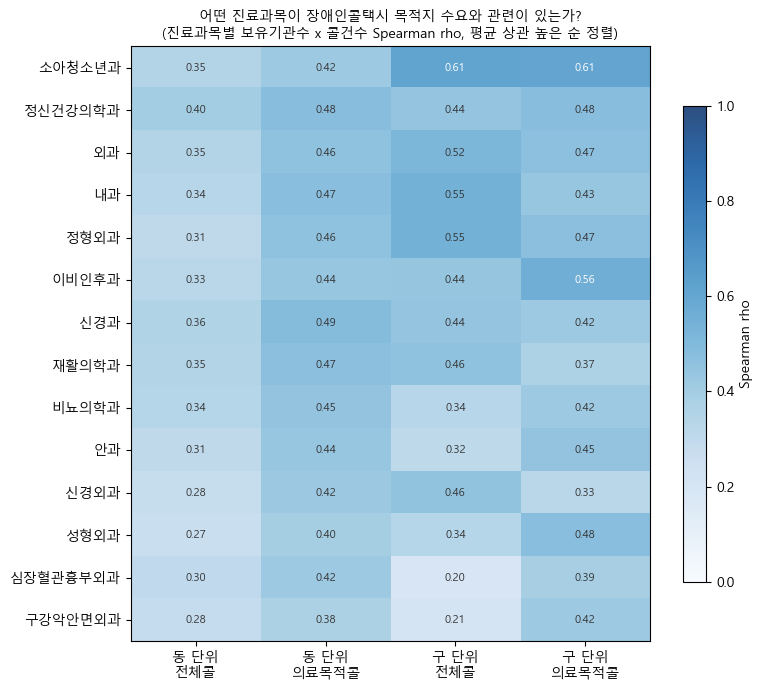

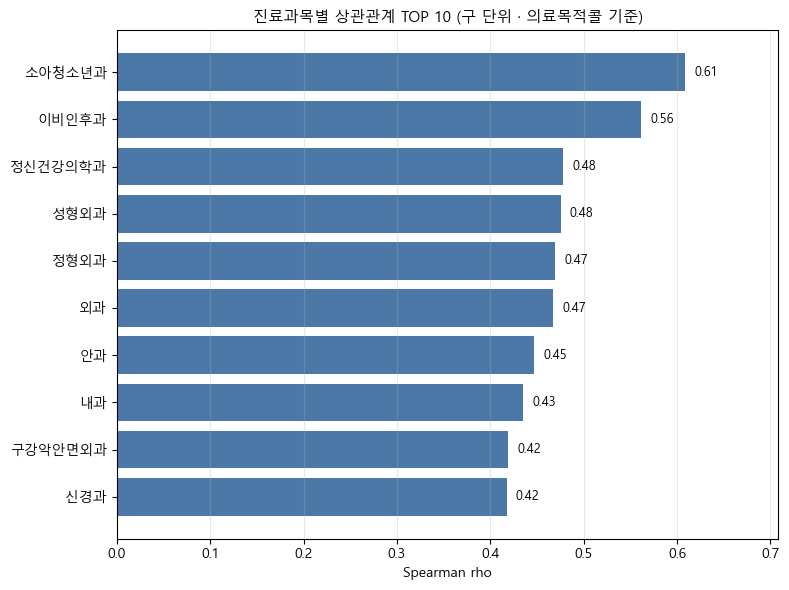

열,전체콜_동,의료목적콜_동,전체콜_구,의료목적콜_구
과목,,,,
소아청소년과,0.351,0.420,0.614,0.608
정신건강의학과,0.399,0.479,0.442,0.478
외과,0.348,0.461,0.519,0.467
내과,0.336,0.474,0.549,0.435
정형외과,0.307,0.459,0.549,0.469
이비인후과,0.325,0.437,0.440,0.562
신경과,0.359,0.492,0.442,0.418
재활의학과,0.351,0.471,0.460,0.374
비뇨의학과,0.340,0.448,0.336,0.416


In [9]:
# 14개 과목 전체 rho 히트맵 + TOP10 막대그래프 (행=과목, 열=전체콜/의료목적콜 x 구/동)
heatmap_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=stats.ConstantInputWarning)
    for region, df_all, df_med in [("동", dong_all, dong_med), ("구", gu_all, gu_med)]:
        for call_type, df in [("전체콜", df_all), ("의료목적콜", df_med)]:
            for subj in CANDIDATE_SUBJECTS:
                col = f"{subj}_보유기관수_5종모집단"
                rho, p = stats.spearmanr(df[col], df["콜건수"])
                heatmap_rows.append({"과목": subj, "열": f"{call_type}_{region}", "rho": rho, "p": p})
heatmap_long = pd.DataFrame(heatmap_rows)
heatmap_wide = heatmap_long.pivot(index="과목", columns="열", values="rho")
COL_ORDER = ["전체콜_동", "의료목적콜_동", "전체콜_구", "의료목적콜_구"]
COL_LABEL = {
    "전체콜_동": "동 단위\n전체콜", "의료목적콜_동": "동 단위\n의료목적콜",
    "전체콜_구": "구 단위\n전체콜", "의료목적콜_구": "구 단위\n의료목적콜",
}
heatmap_wide = heatmap_wide[COL_ORDER]

# 정렬 기준: 4개 조합(동/구 x 전체콜/의료목적콜) 평균 rho — 값이 높은 과목이 위로 오도록 정렬
subject_order = heatmap_wide.mean(axis=1).sort_values(ascending=False).index.tolist()
heatmap_wide = heatmap_wide.loc[subject_order]

# 그래프 1 - 메인: 진료과목별 의료기관 수와 장애인콜택시 수요의 관계
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(heatmap_wide.values, cmap="Blues", vmin=0, vmax=1.0, alpha=0.85, aspect="auto")
ax.set_xticks(range(len(COL_ORDER)))
ax.set_xticklabels([COL_LABEL[c] for c in COL_ORDER])
ax.set_yticks(range(len(subject_order)))
ax.set_yticklabels(subject_order)
for i in range(len(subject_order)):
    for j in range(len(COL_ORDER)):
        val = heatmap_wide.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                color="white" if val > 0.55 else "#333333")
ax.set_title(
    "어떤 진료과목이 장애인콜택시 목적지 수요와 관련이 있는가?\n"
    "(진료과목별 보유기관수 x 콜건수 Spearman rho, 평균 상관 높은 순 정렬)",
    fontsize=10,
)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman rho")
plt.tight_layout()
plt.show()

# 그래프 2 - 핵심 결과 전달용: 진료과목별 상관관계 TOP 10 (구 단위 · 의료목적콜 기준)
RANK_COL = "의료목적콜_구"
top10 = heatmap_wide[RANK_COL].sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color="#4c78a8")
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
ax.set_xlim(0, top10.max() + 0.1)
ax.set_xlabel("Spearman rho")
ax.set_title("진료과목별 상관관계 TOP 10 (구 단위 · 의료목적콜 기준)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(heatmap_wide.round(3))

### Q3 해석

> p-value는 탐색적 참고값으로 해석하며, 14개 과목에 대한 반복 검정 결과를 단일한 유의 관계로 확대해석하지 않는다(§8-4).

- **[확인된 사실] 동 단위에서는 14개 과목 대부분이 비슷한 범위(의료목적콜 기준 0.38~0.49)의 rho를 보인다** — 재활의학과
  (0.471)가 특별히 두드러지지 않고, 신경과(0.492)·정신건강의학과(0.479)·내과(0.474)와 사실상 같은 수준이다. 동 단위만 보면
  "어떤 진료과목이든 병원급 기관이 있는 동은 의료목적콜도 많다"는 일반적 패턴에 가깝다.
- **[탐색적 관계] 구 단위에서는 과목 간 차이가 훨씬 크게 벌어진다.** 전체콜 기준 소아청소년과(0.614)·정형외과(0.549)·
  내과(0.549)가 가장 강하고 심장혈관흉부외과(0.197)·구강악안면외과(0.210)가 가장 약하다(범위 0.20~0.61). 의료목적콜 기준으로는
  **소아청소년과(0.608)와 이비인후과(0.562)가 재활의학과(0.374)보다 뚜렷하게 강하다** — 재활의학과가 이번 분석의 대표 지표로
  선정됐지만, 구 단위·의료목적콜 관계의 강도만 놓고 보면 소아청소년과·이비인후과가 더 강한 후보로 나타난다.
- **[가설]** 동 단위에서는 과목 간 차이가 작고 구 단위에서는 크게 벌어진다는 것은, 개별 진료과목의 특성보다 "그 구에 병원급
  의료기관이 얼마나 몰려 있는가"라는 지역 총량 요인이 구 단위 결과를 더 크게 좌우할 가능성을 시사한다(§8-2 지역 규모 효과와
  연결되는 지점이나, 이번 07_3에서는 외부 데이터 미확보로 직접 검증하지 않았다).
- 소아청소년과·이비인후과는 §12 후속 과제(유의미한 패턴을 보이는 과목의 심층 분석) 후보로 남긴다.

- **왜 그래도 재활의학과인가**: 위 비교에서 재활의학과가 다른 과목 대비 특별히 두드러지지 않는데도, 아래 Q1·Q2·Q2' 심층분석은 재활의학과를 계속 대표 지표로 다룬다 — cell 0의 "장애유형별 분석 후보 진료과목 매핑" 표에서 재활의학과는 15종 장애유형 중 지체·뇌병변·언어장애 3개에 매핑되어, 14개 후보 과목 중 가장 여러 장애유형에 걸치는 과목이기 때문이다 (이 프로젝트 자체의 장애유형 데이터에 근거한 것이며, 외부 정책 문서를 근거로 삼지 않는다). 소아청소년과·이비인후과처럼 구 단위에서 더 강하게 나타난 과목은 후속 심층분석 후보로 별도로 남긴다.


## Q1~Q2 — 핵심 비교 (본 분석, 1단계)

- **Q1**: 병원 수 → 병상 수 → 의사 수 → 진료과목 지표 중 어떤 지표가 목적지 콜건수와 더 강한 탐색적 관계를 보이는가?
- **Q2**: 재활의학과의 보유기관수·전문의수는 기존 의사수 지표와 유사한 지역 패턴을 보이는가?

**"비슷한 패턴"의 판단 기준(§5)**: "비슷하다"처럼 뭉뚱그리지 않고, 두 지표의 Spearman 상관계수 **차이를 숫자로 명시**한다.
p-value는 탐색적 참고값으로만 다루며(다중비교 주의, §8-4), 두 rho가 유의하다고 해서 같다는 뜻은 아니다.


In [10]:
# 커버리지 비교표 — 병상수/의사수(07_2 방식과 동일 로직 재확인) + 재활의학과(07_3 신규) 기관수 기준 커버리지
bed_raw = pd.read_csv(RAW_DIR / "건강보험심사평가원_의료기관별 감염병 및 중증환자 치료시설 현황_20260630.csv", encoding="cp949")
bed_seoul = bed_raw[bed_raw["시도명"] == "서울특별시"]

CLCDNM_NORMALIZE = {"상급종합": "상급종합병원"}
hosp_ref_norm = hosp_ref.copy()
hosp_ref_norm["종별_정규화"] = hosp_ref_norm["clCdNm"].replace(CLCDNM_NORMALIZE)
HOSPITAL_GRADE_7 = ["병원", "종합병원", "요양병원", "상급종합병원", "보건소", "보건지소", "정신병원"]
COVERED_BED_TYPES = ["병원", "종합병원", "요양병원", "상급종합병원", "정신병원"]

grade_ref = hosp_ref_norm[hosp_ref_norm["종별_정규화"].isin(HOSPITAL_GRADE_7)]
n_target_bed = hosp_ref_norm[hosp_ref_norm["종별_정규화"].isin(COVERED_BED_TYPES)].shape[0]
n_target_dr = len(grade_ref)
n_dr_reported = grade_ref["drTotCnt"].notna().sum()

coverage_compare = pd.DataFrame([
    {"지표": "총병상수", "분석대상 종별": "5종_보건소·보건지소제외(상급종합, 종합병원, 병원, 요양병원, 정신병원)",
     "분석대상 기관수": n_target_bed, "데이터 존재 기관수": len(bed_seoul),
     "기관수 기준 커버리지": f"{len(bed_seoul) / n_target_bed:.1%}"},
    {"지표": "의사수_총합", "분석대상 종별": "7종_의원제외(상급종합, 종합병원, 병원, 요양병원, 보건소, 보건지소, 정신병원)",
     "분석대상 기관수": n_target_dr, "데이터 존재 기관수": n_dr_reported,
     "기관수 기준 커버리지": f"{n_dr_reported / n_target_dr:.1%}"},
    {"지표": f"{REP_SUBJECT}_보유기관수(07_3 신규)", "분석대상 종별": "5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소)",
     "분석대상 기관수": len(inst_base), "데이터 존재 기관수": len(inst_base),
     "기관수 기준 커버리지": "100.0%"},
])
display(coverage_compare)
print("주의: '분석대상 종별' 자체가 지표마다 다르다 — 총병상수는 5종_보건소·보건지소제외, 의사수_총합은 7종_의원제외, "
      "재활의학과 지표는 5종_보건지소·정신병원제외 모집단 기준이며 서로 다른 모집단이다. 기관수 기준 커버리지끼리만 비교한다.")


,지표,분석대상 종별,분석대상 기관수,데이터 존재 기관수,기관수 기준 커버리지
0,총병상수,"5종_보건소·보건지소제외(상급종합, 종합병원, 병원, 요양병원, 정신병원)",405,90,22.2%
1,의사수_총합,"7종_의원제외(상급종합, 종합병원, 병원, 요양병원, 보건소, 보건지소, 정신병원)",441,441,100.0%
2,재활의학과_보유기관수(07_3 신규),"5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소)",417,417,100.0%


주의: '분석대상 종별' 자체가 지표마다 다르다 — 총병상수는 5종_보건소·보건지소제외, 의사수_총합은 7종_의원제외, 재활의학과 지표는 5종_보건지소·정신병원제외 모집단 기준이며 서로 다른 모집단이다. 기관수 기준 커버리지끼리만 비교한다.


콜종류                                 의료목적콜    전체콜
지역단위 지표                                         
구    병원_수(7종_의원제외)                  0.430  0.572
     의사수_총합(7종_의원제외)                0.535  0.299
     재활의학과_보유기관수(5종_보건지소·정신병원제외)    0.374  0.460
     재활의학과_전문의수_총합(5종_보건지소·정신병원제외)  0.573  0.503
     총병상수(5종_보건소·보건지소제외)            0.635  0.380
동    병원_수(7종_의원제외)                  0.481  0.354
     의사수_총합(7종_의원제외)                0.581  0.415
     재활의학과_보유기관수(5종_보건지소·정신병원제외)    0.471  0.351
     재활의학과_전문의수_총합(5종_보건지소·정신병원제외)  0.517  0.397
     총병상수(5종_보건소·보건지소제외)            0.498  0.416

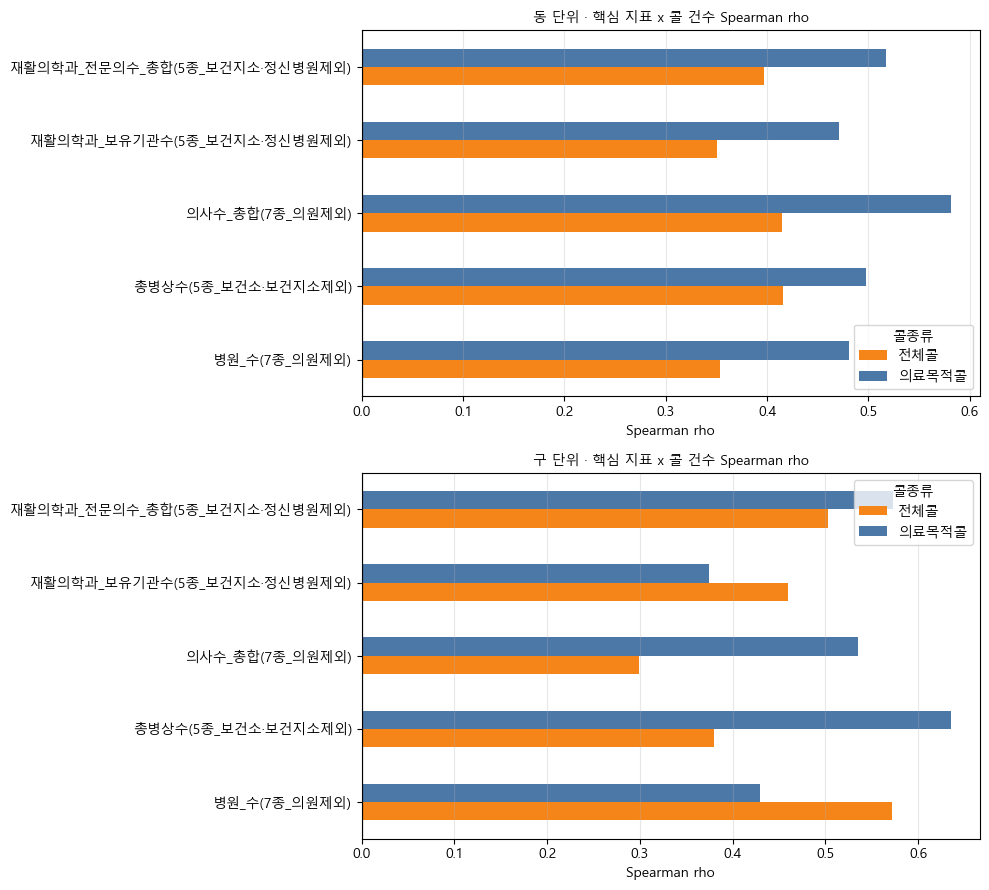

In [11]:
# 핵심 지표 5개 x 전체콜/의료목적콜 x 동/구 Spearman rho — 07_2 형식(그룹 막대) 유지
CORE_METRICS = ["병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합",
                 f"{REP_SUBJECT}_보유기관수_5종모집단", f"{REP_SUBJECT}_전문의수_총합_5종모집단"]
METRIC_LABEL = {
    "병원급_총수(의원/한의원제외)": "병원_수(7종_의원제외)",
    "총병상수": "총병상수(5종_보건소·보건지소제외)",
    "의사수_총합": "의사수_총합(7종_의원제외)",
    f"{REP_SUBJECT}_보유기관수_5종모집단": f"{REP_SUBJECT}_보유기관수(5종_보건지소·정신병원제외)",
    f"{REP_SUBJECT}_전문의수_총합_5종모집단": f"{REP_SUBJECT}_전문의수_총합(5종_보건지소·정신병원제외)",
}

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=stats.ConstantInputWarning)
    for region, df_all, df_med in [("동", dong_all, dong_med), ("구", gu_all, gu_med)]:
        for call_type, df in [("전체콜", df_all), ("의료목적콜", df_med)]:
            for m in CORE_METRICS:
                rho, p = stats.spearmanr(df[m], df["콜건수"])
                rows.append({"지역단위": region, "콜종류": call_type, "지표": METRIC_LABEL[m],
                             "Spearman rho": round(rho, 3), "p": p, "n": len(df)})
core_rho = pd.DataFrame(rows)
display(core_rho.pivot(index=["지역단위", "지표"], columns="콜종류", values="Spearman rho"))

NL = chr(10)
CALL_TYPE_COLOR = {"전체콜": "#f58518", "의료목적콜": "#4c78a8"}
fig, axes = plt.subplots(2, 1, figsize=(10, 9))
for ax, region in zip(axes, ["동", "구"]):
    pivot = core_rho[core_rho["지역단위"] == region].pivot(
        index="지표", columns="콜종류", values="Spearman rho"
    ).loc[[METRIC_LABEL[m] for m in CORE_METRICS]][["전체콜", "의료목적콜"]]
    pivot.plot(kind="barh", ax=ax, color=[CALL_TYPE_COLOR["전체콜"], CALL_TYPE_COLOR["의료목적콜"]])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{region} 단위 · 핵심 지표 x 콜 건수 Spearman rho", fontsize=10)
    ax.set_xlabel("Spearman rho")
    ax.set_ylabel("")
    ax.legend(title="콜종류")
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
print(
    "재활의학과 등 진료과목 지표는 5종_보건지소·정신병원제외"
    "(상급종합, 종합병원, 병원, 요양병원, 보건소) 417개 모집단 기준"
)
print()

# §5-1 최종 비교표 — ρ 차이 수치화 포함(의사수_총합 대비)
final_table_rows = []
for region in ["동", "구"]:
    sub = core_rho[core_rho["지역단위"] == region]
    dr_rho = {ct: sub[(sub["지표"] == "의사수_총합(7종_의원제외)") & (sub["콜종류"] == ct)]["Spearman rho"].iloc[0]
              for ct in ["전체콜", "의료목적콜"]}
    for m in CORE_METRICS:
        label = METRIC_LABEL[m]
        row = {"지표": label, "구/동": region}
        for ct in ["전체콜", "의료목적콜"]:
            rho_val = sub[(sub["지표"] == label) & (sub["콜종류"] == ct)]["Spearman rho"].iloc[0]
            row[f"{ct} rho"] = rho_val
            row[f"{ct} |차이 vs 의사수_총합|"] = round(abs(rho_val - dr_rho[ct]), 3)
        final_table_rows.append(row)
final_comparison_table = pd.DataFrame(final_table_rows)
display(final_comparison_table)


재활의학과 등 진료과목 지표는 5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소) 417개 모집단 기준



,지표,구/동,전체콜 rho,전체콜 |차이 vs 의사수_총합|,의료목적콜 rho,의료목적콜 |차이 vs 의사수_총합|
0,병원_수(7종_의원제외),동,0.354,0.061,0.481,0.100
1,총병상수(5종_보건소·보건지소제외),동,0.416,0.001,0.498,0.083
2,의사수_총합(7종_의원제외),동,0.415,0.000,0.581,0.000
3,재활의학과_보유기관수(5종_보건지소·정신병원제외),동,0.351,0.064,0.471,0.110
4,재활의학과_전문의수_총합(5종_보건지소·정신병원제외),동,0.397,0.018,0.517,0.064
5,병원_수(7종_의원제외),구,0.572,0.273,0.430,0.105
6,총병상수(5종_보건소·보건지소제외),구,0.380,0.081,0.635,0.100
7,의사수_총합(7종_의원제외),구,0.299,0.000,0.535,0.000
8,재활의학과_보유기관수(5종_보건지소·정신병원제외),구,0.460,0.161,0.374,0.161
9,재활의학과_전문의수_총합(5종_보건지소·정신병원제외),구,0.503,0.204,0.573,0.038


### Q1·Q2 해석

- **[확인된 사실] 지표를 병원 수 → 병상 수 → 의사 수 → 재활의학과 지표로 바꿔도 콜 건수와의 양의 관계 자체는 유지된다.** 다만
  어느 지표가 가장 강한지는 지역단위·콜종류에 따라 계속 달라진다(07_1·07_2에서 이미 확인된 패턴이 진료과목 지표에서도 재현됨).
  - 동 단위·의료목적콜 기준으로는 **의사수_총합(0.581)**이 5개 지표 중 가장 강하고, 재활의학과_전문의수_총합(0.517)이
    그다음으로 강하다 — 병원_수(0.481)보다도 재활의학과_전문의수_총합이 앞선다.
  - 구 단위·의료목적콜 기준으로는 **총병상수(0.635)**가 가장 강하지만, 놀랍게도 **재활의학과_전문의수_총합(0.573)이
    의사수_총합(0.535)보다 근소하게 더 강하다.** 반면 재활의학과_보유기관수(0.374)는 의사수_총합보다 뚜렷이 약하다.
  - 구 단위·전체콜 기준으로는 병원_수(0.572)가 가장 강하고 의사수_총합(0.299)이 오히려 가장 약하다 — 07_2에서 이미 관찰된
    "병원_수는 구 단위 전체콜에서 강하지만 의사수는 그렇지 않다"는 불일치가 여기서도 유지된다.
- **[탐색적 관계] 재활의학과 두 지표(보유기관수 vs 전문의수_총합)는 동 단위에서는 의사수_총합과 비슷한 패턴**(차이 0.018~0.064)을
  보이지만, **구 단위에서는 서로 다른 패턴**을 보인다 — 의사수_총합은 의료목적콜(0.535)에서 전체콜(0.299)보다 훨씬 강한 반면,
  재활의학과_보유기관수는 오히려 전체콜(0.460)에서 의료목적콜(0.374)보다 강하다(방향 자체가 반대). 재활의학과_전문의수_총합은
  의사수_총합과 같은 방향(의료목적콜에서 더 강함)을 유지한다 — 즉 같은 "재활의학과"라도 보유기관수와 전문의수 중 무엇을 보느냐에
  따라 구 단위 결론이 갈릴 수 있다.
- **[가설]** 구 단위에서 재활의학과_전문의수_총합이 의사수_총합보다 근소하게 강하다는 점은, 병원급 전체 의사 수보다 특정
  진료과목(재활의학과)의 전문의 배치가 목적지 선택과 더 밀접할 가능성을 시사한다 — 다만 |차이|가 0.038(구·의료목적콜)로 크지
  않아 확대해석하지 않는다.

**표현 원칙 준수**: "비슷하다"가 아니라 위처럼 rho 차이를 숫자로 명시했다. p-value는 §5-1 표에는 표기하지 않았으나(탐색적 참고값
원칙, §8-4) 모든 rho가 n=25(구)/n=416~431(동) 표본에서 나온 값임을 함께 고려한다.


## Q2' — 개별 종별 세분화 (0단계)

**Q2'**: 재활의학과 관계는 5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소) 중 특정 종별이 주도하는가, 아니면 종별 전반에 고르게 나타나는가?

(보건지소·정신병원·의원은 이 비교에서 제외한다 — 근거: 07_2 cell 7, 의료목적콜과의 상관관계가 약함.)


,콜종류,종별,Spearman rho,p,재활의학과 보유 기관수
0,전체콜,상급종합,0.203,2.12e-05,14
1,전체콜,종합병원,0.282,2.56e-09,28
2,전체콜,병원,0.139,3.87e-03,92
3,전체콜,요양병원,0.218,4.97e-06,86
4,전체콜,보건소,NaN,정의불가(분산 0),0
5,의료목적콜,상급종합,0.283,4.13e-09,14
6,의료목적콜,종합병원,0.351,1.77e-13,28
7,의료목적콜,병원,0.226,3.07e-06,92
8,의료목적콜,요양병원,0.226,3.31e-06,86
9,의료목적콜,보건소,NaN,정의불가(분산 0),0


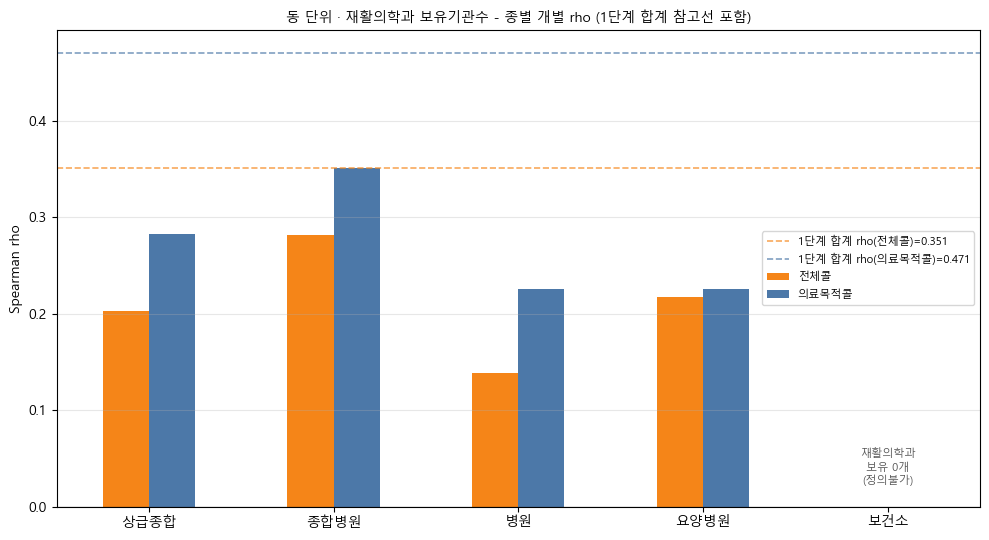

In [13]:
# 5개 종별(5종_보건지소·정신병원제외: 상급종합, 종합병원, 병원, 요양병원, 보건소) x 콜종류 Spearman rho + 1단계(5종 합계) 참고선
# 보건소는 재활의학과 보유 기관이 전원(全院) 0개라 분산이 없어 rho 자체가 정의되지 않는다(ConstantInputWarning) —
# "관계가 약하다"가 아니라 "관측할 변동이 없다"는 뜻이므로 NaN을 그대로 두고 표/차트에서 별도 표기한다.
type_rho_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=stats.ConstantInputWarning)
    for call_type, df in [("전체콜", dong_all), ("의료목적콜", dong_med)]:
        for t in FIVE_TYPES:
            col = f"재활의학과_보유기관수_{t}"
            n_holding = int((inst_base.loc[inst_base["clCdNm"] == t, f"{REP_SUBJECT}_보유여부"]).sum())
            if n_holding == 0:
                rho, p = float("nan"), float("nan")
            else:
                rho, p = stats.spearmanr(df[col], df["콜건수"])
            type_rho_rows.append({"콜종류": call_type, "종별": t, "Spearman rho": round(rho, 3) if pd.notna(rho) else np.nan,
                                   "p": f"{p:.2e}" if pd.notna(p) else "정의불가(분산 0)",
                                   "재활의학과 보유 기관수": n_holding})
type_rho = pd.DataFrame(type_rho_rows)
display(type_rho)

ref_line = {ct: core_rho[(core_rho["지역단위"] == "동") & (core_rho["콜종류"] == ct) &
                          (core_rho["지표"] == f"{REP_SUBJECT}_보유기관수(5종_보건지소·정신병원제외)")]["Spearman rho"].iloc[0]
            for ct in ["전체콜", "의료목적콜"]}

fig, ax = plt.subplots(figsize=(10, 5.5))
pivot = type_rho.pivot(index="종별", columns="콜종류", values="Spearman rho").loc[FIVE_TYPES][["전체콜", "의료목적콜"]]
pivot.plot(kind="bar", ax=ax, color=[CALL_TYPE_COLOR["전체콜"], CALL_TYPE_COLOR["의료목적콜"]])
ax.axhline(0, color="black", linewidth=0.8)
for ct, color in CALL_TYPE_COLOR.items():
    ax.axhline(ref_line[ct], color=color, linestyle="--", linewidth=1.2, alpha=0.7,
               label=f"1단계 합계 rho({ct})={ref_line[ct]:.3f}")
bogunso_idx = FIVE_TYPES.index("보건소")
ax.text(bogunso_idx, 0.02, "재활의학과\n보유 0개\n(정의불가)", ha="center", va="bottom", fontsize=8, color="#555555")
ax.set_title("동 단위 · 재활의학과 보유기관수 - 종별 개별 rho (1단계 합계 참고선 포함)", fontsize=10)
ax.set_ylabel("Spearman rho")
ax.set_xlabel("")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Q2' 해석

- **[확인된 사실] 종합병원이 5개 종별 중 재활의학과-콜건수 관계를 가장 크게 주도한다**(전체콜 rho=0.282, 의료목적콜 rho=0.351,
  둘 다 p<0.001). 상급종합병원(0.203→0.283)과 요양병원(0.218→0.226)도 유의하지만 종합병원보다는 약하고, 병원이 가장 약하다
  (0.139→0.226) — 병원급이 232개로 5종 중 가장 많은 개수를 차지하지만, 재활의학과 관계를 주도하는 것은 개수가 아니라 종합병원이다.
- **[중요 발견] 보건소는 25개 기관 전부 재활의학과를 보유하지 않아(0/25) Spearman rho 자체가 정의되지 않는다**(분산 0). 이는
  "관계가 약하다"가 아니라 "관측할 변동이 아예 없다"는 뜻이며, 07_1·07_2에서 보건소가 정신·보건 계열(그룹1)로 분류돼 병원급
  의료기관(그룹2)보다 일관되게 약한 관계를 보였던 것과 같은 맥락에서 이해할 수 있다.
- **[탐색적 관계] 개별 종별 중 최댓값(종합병원, 의료목적콜 0.351)이 1단계 합계(5종 전체, 0.471)보다 낮다** — 개별 종별을
  쪼개 보는 것보다 5종을 합쳐서 볼 때 관계가 더 뚜렷해진다. 이는 07_2 A섹션에서 "종별을 그룹으로 묶으면 노이즈가 줄어든다"고
  관찰된 패턴과 같은 방향이다.
- **07_1 상급종합병원 이슈 재현 여부**: 07_1·07_2에서는 구 단위에서 상급종합병원의 콜 종류별 부호가 반대로 뒤집혔다(전체콜
  음수, 의료목적콜 양수). 이번 0단계는 **동 단위**로만 봤는데, 상급종합병원의 재활의학과 지표는 전체콜(0.203)·의료목적콜(0.283)
  모두 양의 상관으로 부호 반전이 나타나지 않았다 — 다만 이는 동/구 단위가 다르기 때문일 수 있어 직접적인 재현 여부 확인은 아니다.
- **표본 크기 주의**: 상급종합(14개)·종합병원(45개)은 병원(232개)·요양병원(101개)보다 기관 수 자체가 훨씬 적어, 이 종별들의
  rho는 참고 수준으로 다룬다.


## Q4 — 총량 vs 구성, 규모 효과

구·동마다 인구·상업지역 규모·의료기관 밀집도가 다르므로, 단순 총량 상관만으로는 "의료기관이 많아서 콜이 많다"고 단정할 수 없다
(상관≠인과 원칙의 통계적 보강, §8-2). 인구 대비 의료기관 수, 의료기관 1개당 목적지 건수 등 보정 분석은 **외부 인구·면적 데이터
확보 가능 여부를 먼저 확인한 뒤 수행**하기로 했으나, 프로젝트 데이터 폴더에 해당 데이터가 없음을 확인했다(2026-09-08).

**따라서 이번 07_3에서는 규모 보정 분석을 수행하지 않는다** — 임의로 새 데이터를 만들어 붙이지 않고, 기본 분석(총량 기준)만 유지한다.
외부 데이터를 확보하면 §12 후속 과제로 다시 다룬다.


In [14]:
# 마포구 재검증 - 07_1(병상수 0) -> 07_2(의사수_총합 65명) -> 07_3(재활의학과 지표)
TRACK_COLS = ["목적구", "콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합",
              f"{REP_SUBJECT}_보유기관수_5종모집단", f"{REP_SUBJECT}_전문의수_총합_5종모집단"]
for df, label in [(gu_all, "전체콜"), (gu_med, "의료목적콜")]:
    row = df[df["목적구"] == "마포구"][TRACK_COLS]
    print(f"--- {label} ---")
    display(row)


--- 전체콜 ---


,목적구,콜건수,병원급_총수(의원/한의원제외),총병상수,의사수_총합,재활의학과_보유기관수_5종모집단,재활의학과_전문의수_총합_5종모집단
12,마포구,73304,10,0.0,65,4,6


--- 의료목적콜 ---


,목적구,콜건수,병원급_총수(의원/한의원제외),총병상수,의사수_총합,재활의학과_보유기관수_5종모집단,재활의학과_전문의수_총합_5종모집단
12,마포구,5248,10,0.0,65,4,6


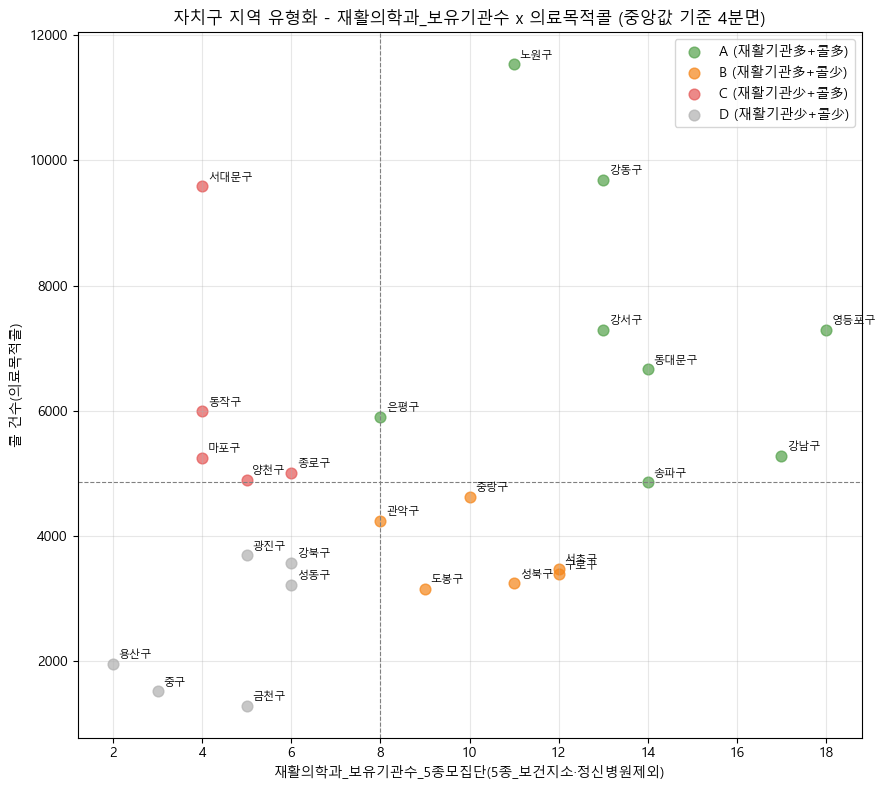

,목적구,유형,콜건수,병원급_총수(의원/한의원제외),총병상수,의사수_총합,재활의학과_보유기관수_5종모집단
8,노원구,A (재활기관多+콜多),11531,17,435.0,671,11
1,강동구,A (재활기관多+콜多),9692,27,509.0,1025,13
13,서대문구,C (재활기관少+콜多),9587,11,312.0,1376,4
3,강서구,A (재활기관多+콜多),7295,30,144.0,594,13
19,영등포구,A (재활기관多+콜多),7292,27,223.0,841,18
10,동대문구,A (재활기관多+콜多),6664,25,210.0,732,14
11,동작구,C (재활기관少+콜多),5994,9,216.0,667,4
21,은평구,A (재활기관多+콜多),5902,23,194.0,453,8
0,강남구,A (재활기관多+콜多),5287,43,396.0,2283,17
12,마포구,C (재활기관少+콜多),5248,10,0.0,65,4


In [15]:
# 자치구 4분면 유형화 - 재활의학과_보유기관수_5종모집단 x 의료목적콜 (중앙값 기준선 고정, §8-5)
gu_q_rehab = gu_med.copy()
xcol = f"{REP_SUBJECT}_보유기관수_5종모집단"
med_x = gu_q_rehab[xcol].median()
med_y = gu_q_rehab["콜건수"].median()

def classify(row):
    if row[xcol] >= med_x and row["콜건수"] >= med_y:
        return "A (재활기관多+콜多)"
    if row[xcol] >= med_x and row["콜건수"] < med_y:
        return "B (재활기관多+콜少)"
    if row[xcol] < med_x and row["콜건수"] >= med_y:
        return "C (재활기관少+콜多)"
    return "D (재활기관少+콜少)"

gu_q_rehab["유형"] = gu_q_rehab.apply(classify, axis=1)
colors = {"A (재활기관多+콜多)": "#54a24b", "B (재활기관多+콜少)": "#f58518",
          "C (재활기관少+콜多)": "#e45756", "D (재활기관少+콜少)": "#b0b0b0"}

fig, ax = plt.subplots(figsize=(9, 8))
for label, sub in gu_q_rehab.groupby("유형"):
    ax.scatter(sub[xcol], sub["콜건수"], s=60, alpha=0.7, label=label, color=colors[label])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row[xcol], row["콜건수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(med_x, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"{xcol}(5종_보건지소·정신병원제외)")
ax.set_ylabel("콜 건수(의료목적콜)")
ax.set_title("자치구 지역 유형화 - 재활의학과_보유기관수 x 의료목적콜 (중앙값 기준 4분면)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_q_rehab.sort_values("콜건수", ascending=False)[
    ["목적구", "유형", "콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합", xcol]
])


### Q5 해석

- **[확인된 사실] 마포구는 07_1 → 07_2 → 07_3에 걸쳐 일관되게 "인프라 少 + 콜 多" 지역으로 나타난다.** 07_1에서 총병상수 0,
  07_2에서 의사수_총합 65명(소규모나마 존재), 이번 07_3에서 재활의학과_보유기관수 4개(자치구 중앙값 미만)로 — 규모 지표를
  무엇으로 바꿔도 "인프라는 상대적으로 작지만 의료목적콜은 5,248건으로 상당히 많다"는 유형(C, 재활기관少+콜多)이 유지된다.
- 25개 구를 재활의학과_보유기관수 × 의료목적콜 중앙값 기준 4분면으로 나누면 **A(재활기관多+콜多) 8개, B(재활기관多+콜少) 6개,
  C(재활기관少+콜多) 5개, D(재활기관少+콜少) 6개**로 나뉜다.
- **[탐색적 관계]** C유형(마포구·서대문구·동작구·종로구·양천구)은 재활의학과 보유기관 수는 적지만 의료목적콜은 중앙값 이상인
  지역이라, 재활의학과 인프라 확충이 필요한 후보 지역으로 볼 수 있다. 특히 **종로구**는 병원_수(9개)·재활의학과_보유기관수(6개)는
  적은 편이지만 의사수_총합(2,002명)은 25개 구 중 최상위권이다 — 07_2에서 확인된 "상급종합병원이 소수 구에 집중된다"는 관찰과
  같은 구가 재활의학과 기준으로도 비슷한 양상(소수 대형 기관에 자원이 집중)을 보인다.
- **[가설]** C유형 지역은 대형·전문 의료기관(상급종합병원 등)이 있어 의사수 총합은 높지만, 그 기관들이 반드시 재활의학과를
  운영하는 것은 아니어서 재활의학과 보유기관수 기준으로는 상대적으로 낮게 나타날 수 있다 — 이 가설을 검증하려면 기관별 진료과목
  구성을 더 세밀히 들여다봐야 하며, 이번 07_3 범위에서는 확정하지 않는다.

**한계**: 위 상관은 전부 탐색적 관계이며, 진료과목별 기관 분포가 콜택시 이용을 직접 증가시킨다는 인과관계를 의미하지 않는다.
구 단위 집계(n=25)에서는 생태학적 오류(ecological fallacy) 가능성이 있다. 보유기관수·전문의수는 의료서비스의 지역적
분포/전문인력 규모의 대리 지표일 뿐, 실제 접근성이나 이용 가능성을 직접 측정하는 지표는 아니다(§8-3).


### Q5 보충 — 재활의학과_전문의수_총합 기준 4분면 재검증

앞선 Q1·Q2 핵심비교 섹션에서 구 단위·의료목적콜 기준 rho가 재활의학과_보유기관수(0.374)보다 재활의학과_전문의수_총합(0.573)이 더 강했다. 위 4분면(보유기관수 기준)에서 나온 "재활 인프라 확충 후보(C유형)" 목록이 지표를 전문의수로 바꿔도 동일하게 유지되는지 확인한다.


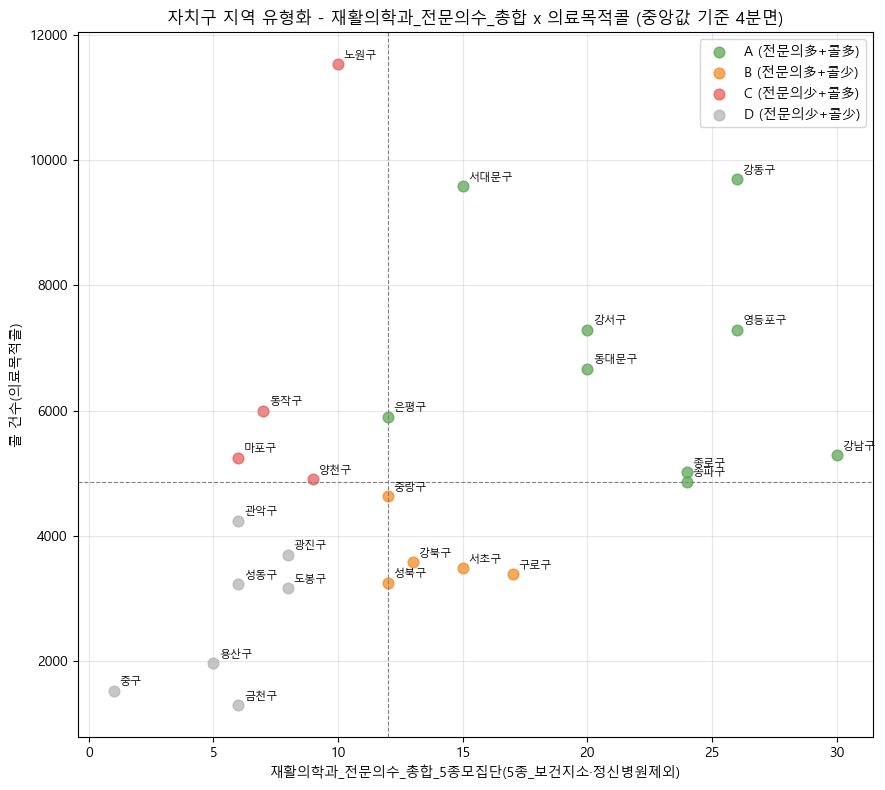

[비교] 25개 구 중 6개 구가 지표(보유기관수 vs 전문의수)에 따라 유형이 바뀐다.


,목적구,유형_보유기관수,재활의학과_전문의수_총합_5종모집단,콜건수,유형_전문의수,유형변화
8,노원구,A (재활기관多+콜多),10,11531,C (전문의少+콜多),True
1,강동구,A (재활기관多+콜多),26,9692,A (전문의多+콜多),False
13,서대문구,C (재활기관少+콜多),15,9587,A (전문의多+콜多),True
3,강서구,A (재활기관多+콜多),20,7295,A (전문의多+콜多),False
19,영등포구,A (재활기관多+콜多),26,7292,A (전문의多+콜多),False
10,동대문구,A (재활기관多+콜多),20,6664,A (전문의多+콜多),False
11,동작구,C (재활기관少+콜多),7,5994,C (전문의少+콜多),False
21,은평구,A (재활기관多+콜多),12,5902,A (전문의多+콜多),False
0,강남구,A (재활기관多+콜多),30,5287,A (전문의多+콜多),False
12,마포구,C (재활기관少+콜多),6,5248,C (전문의少+콜多),False


In [16]:
# Q5 보충 — 재활의학과_전문의수_총합_5종모집단 기준 4분면 재검증(중앙값 기준선 고정, §8-5)
gu_q_doc = gu_med.copy()
xcol_doc = f"{REP_SUBJECT}_전문의수_총합_5종모집단"
med_x_doc = gu_q_doc[xcol_doc].median()
med_y = gu_q_doc["콜건수"].median()


def classify_doc(row):
    if row[xcol_doc] >= med_x_doc and row["콜건수"] >= med_y:
        return "A (전문의多+콜多)"
    if row[xcol_doc] >= med_x_doc and row["콜건수"] < med_y:
        return "B (전문의多+콜少)"
    if row[xcol_doc] < med_x_doc and row["콜건수"] >= med_y:
        return "C (전문의少+콜多)"
    return "D (전문의少+콜少)"


gu_q_doc["유형"] = gu_q_doc.apply(classify_doc, axis=1)
colors_doc = {"A (전문의多+콜多)": "#54a24b", "B (전문의多+콜少)": "#f58518",
              "C (전문의少+콜多)": "#e45756", "D (전문의少+콜少)": "#b0b0b0"}

fig, ax = plt.subplots(figsize=(9, 8))
for label, sub in gu_q_doc.groupby("유형"):
    ax.scatter(sub[xcol_doc], sub["콜건수"], s=60, alpha=0.7, label=label, color=colors_doc[label])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row[xcol_doc], row["콜건수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(med_x_doc, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"{xcol_doc}(5종_보건지소·정신병원제외)")
ax.set_ylabel("콜 건수(의료목적콜)")
ax.set_title("자치구 지역 유형화 - 재활의학과_전문의수_총합 x 의료목적콜 (중앙값 기준 4분면)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 보유기관수 기준(위 cell, gu_q_rehab) 유형과 병합 비교 — 지표를 바꾸면 유형 분류가 얼마나 달라지는가
compare = gu_q_rehab[["목적구", "유형"]].rename(columns={"유형": "유형_보유기관수"}).merge(
    gu_q_doc[["목적구", xcol_doc, "콜건수", "유형"]].rename(columns={"유형": "유형_전문의수"}), on="목적구"
)
compare["유형변화"] = (compare["유형_보유기관수"].str.split(" ").str[0]
                    != compare["유형_전문의수"].str.split(" ").str[0])

print(f"[비교] 25개 구 중 {compare['유형변화'].sum()}개 구가 지표(보유기관수 vs 전문의수)에 따라 유형이 바뀐다.")
display(compare.sort_values("콜건수", ascending=False))


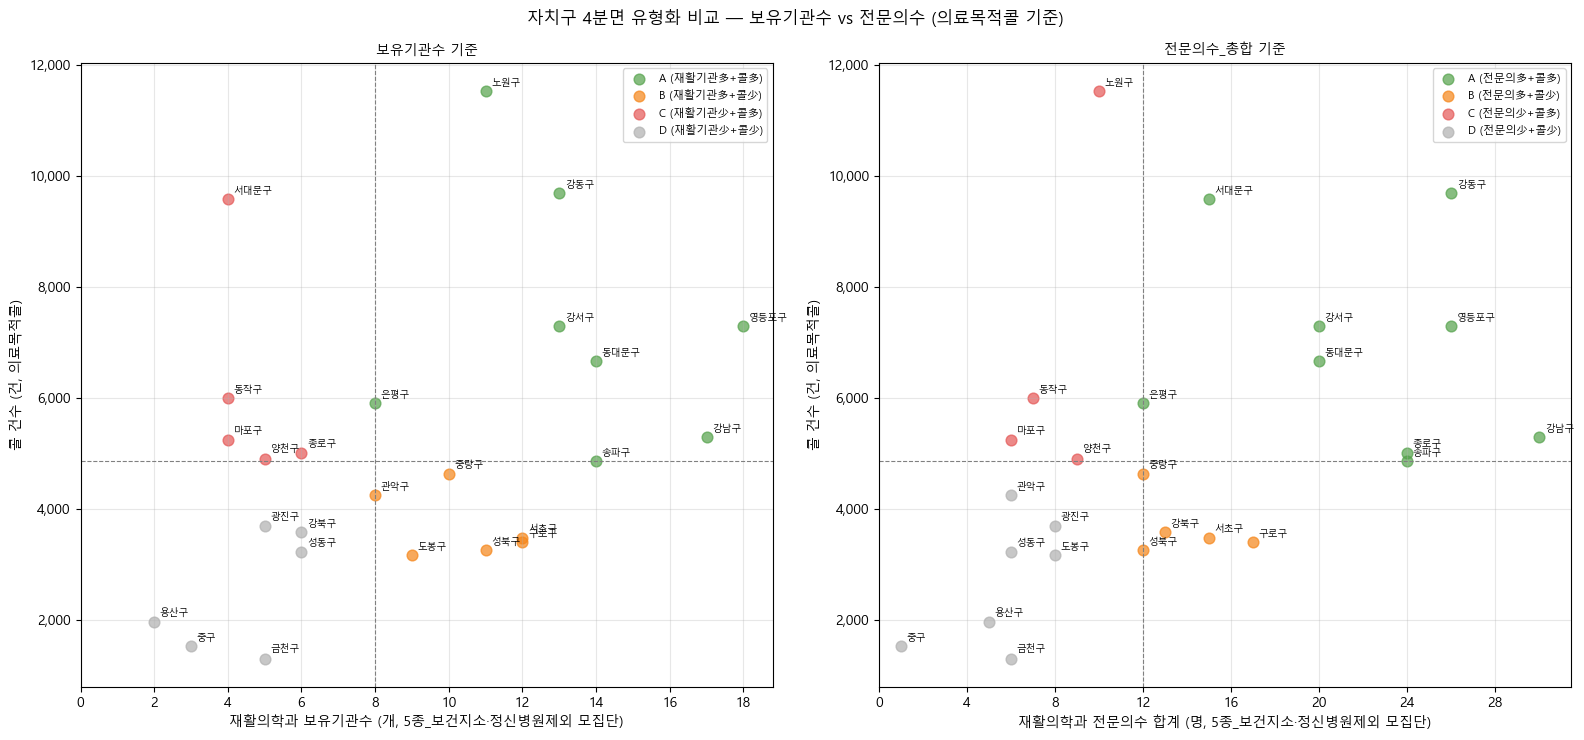

: 

In [ ]:
# 보유기관수 기준 vs 전문의수 기준 4분면 나란히 비교 — 보유기관수 기준 vs 전문의수 기준 4분면을 한 화면에서 대조
from matplotlib.ticker import MaxNLocator, FuncFormatter

QUAD_COLOR = {"A": "#54a24b", "B": "#f58518", "C": "#e45756", "D": "#b0b0b0"}
COMMA_FMT = FuncFormatter(lambda x, _: f"{int(x):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

ax = axes[0]
for label, sub in gu_q_rehab.groupby("유형"):
    quad = label[0]
    ax.scatter(sub[xcol], sub["콜건수"], s=60, alpha=0.7, label=label, color=QUAD_COLOR[quad])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row[xcol], row["콜건수"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axvline(med_x, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlim(left=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(COMMA_FMT)
ax.set_xlabel("재활의학과 보유기관수 (개, 5종_보건지소·정신병원제외 모집단)")
ax.set_ylabel("콜 건수 (건, 의료목적콜)")
ax.set_title("보유기관수 기준", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for label, sub in gu_q_doc.groupby("유형"):
    quad = label[0]
    ax.scatter(sub[xcol_doc], sub["콜건수"], s=60, alpha=0.7, label=label, color=QUAD_COLOR[quad])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row[xcol_doc], row["콜건수"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axvline(med_x_doc, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlim(left=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(axis="y", labelleft=True)
ax.yaxis.set_major_formatter(COMMA_FMT)
ax.set_xlabel("재활의학과 전문의수 합계 (명, 5종_보건지소·정신병원제외 모집단)")
ax.set_ylabel("콜 건수 (건, 의료목적콜)")
ax.set_title("전문의수_총합 기준", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("자치구 4분면 유형화 비교 — 보유기관수 vs 전문의수 (의료목적콜 기준)", fontsize=12)
plt.tight_layout()
plt.show()

### Q5 보충 해석

- **[확인된 사실] 지표를 보유기관수 → 전문의수_총합으로 바꾸면 25개 구 중 6개 구(24%)의 유형이 바뀐다** — 우선순위 판단에 실제로 영향을 주는 수준의 차이다.
- **C유형("재활 인프라 부족+콜 多", 확충 후보) 목록 자체가 바뀐다.** 보유기관수 기준 C유형은 마포·서대문·동작·종로·양천구(5개)였으나, 전문의수 기준으로는 **서대문구·종로구가 A유형(전문의多+콜多)으로 빠지고 노원구가 새로 C유형에 들어와** 마포·동작·양천·노원구(4개)로 바뀐다.
- 서대문구·종로구는 앞선 Q1·Q2 핵심비교 섹션에서 이미 확인했듯 **재활의학과 보유기관 수는 적지만(서대문 4개, 종로 6개) 소수 기관에 전문의가 집중돼(기관당 3.75명·4.0명, 25개 구 중 최상위권) 실질 진료 capacity는 높은 지역**이다 — 보유기관수만 보면 "인프라 부족"으로 오분류될 수 있다.
- 반대로 **노원구는 콜 건수(의료목적콜 11,531건, 25개 구 중 1위)에 비해 재활의학과 전문의수(10명)가 상대적으로 적어**, 전문의수 기준에서만 확충 후보(C유형)로 새로 잡힌다.
- **결론(유의미함)**: 이번 비교는 유의미하다 — 단순히 지표를 하나 더 그려본 수준이 아니라, **어떤 지표를 쓰느냐에 따라 "확충이 필요해 보이는 자치구" 목록 자체가 달라진다.** 두 지표(보유기관수=존재 여부, 전문의수=서비스 규모)는 서로 다른 걸 측정하므로, 후속 논의·팀 공유 시에는 어느 한쪽만으로 결론짓지 말고 두 유형표를 함께 제시하는 것이 안전하다.
- **한계**: 이 유형화도 다른 4분면 분석과 마찬가지로 탐색적 관계이며, 구 단위(n=25) 표본이 작아 중앙값 기준선 근처에 있는 구는 두 지표 중 무엇을 쓰느냐에 따라 유형이 쉽게 뒤집힐 수 있다는 점을 감안해야 한다(생태학적 오류 가능성 포함, §8-3).


In [18]:
# 최종 검증 - 07_1/07_2 대비 행 수 보존, 키 중복 없음, 기존 컬럼 합계 불변, 신규 컬럼 존재
NEW_COLS_DONG = SPECIALTY_COLS + REHAB_TYPE_COLS
NEW_COLS_GU = SPECIALTY_COLS

checks = []
for name, df in DATASETS.items():
    key_cols = ["목적구", "행정동"] if "행정동" in df.columns else ["목적구"]
    new_cols = NEW_COLS_DONG if "행정동" in df.columns else NEW_COLS_GU
    row_ok = len(df) == PRE_LEN[name]
    dup_ok = not df.duplicated(subset=key_cols).any()
    sums_ok = all(df[c].sum() == ORIGINAL_SUMS[name][c] for c in ["콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합"])
    newcols_ok = all(c in df.columns for c in new_cols)
    checks.append({"데이터셋": name, "행 수 보존": row_ok, "키 중복 없음": dup_ok,
                   "기존 컬럼 합계 불변": sums_ok, "신규 컬럼 존재": newcols_ok})
check_df = pd.DataFrame(checks)
display(check_df)
assert check_df.drop(columns="데이터셋").all(axis=None), "검증 실패 항목이 있다 - 저장 중단"
print("[검증 통과] 4개 데이터셋 모두 행 수 보존·키 중복 없음·기존 컬럼 합계 불변·신규 컬럼 존재 확인")

# 결과 저장 - 07_2 산출물은 read-only로 보존, 07_3 신규 컬럼이 추가된 결과만 별도 파일로 저장
SAVE_SPECS = {
    "dong_all": ("region_dong_call_hospital_combined_07_3_진료과목추가.csv", "콜택시_목적지_건수"),
    "dong_med": ("region_dong_call_hospital_combined_medical_07_3_진료과목추가.csv", "콜택시_의료목적지_건수"),
    "gu_all": ("region_gu_call_hospital_combined_07_3_진료과목추가.csv", "콜택시_목적지_건수"),
    "gu_med": ("region_gu_call_hospital_combined_medical_07_3_진료과목추가.csv", "콜택시_의료목적지_건수"),
}
for name, (filename, call_col) in SAVE_SPECS.items():
    df_out = DATASETS[name].rename(columns={"콜건수": call_col})
    out_path = PROCESSED_DIR / filename
    df_out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"저장 완료: {out_path} ({df_out.shape[0]}행 x {df_out.shape[1]}열)")

print("\n[주의] 이 CSV 4종을 이후 다른 노트북에서 다시 불러올 때는 사용 전 결측치를 반드시 확인한다.")


,데이터셋,행 수 보존,키 중복 없음,기존 컬럼 합계 불변,신규 컬럼 존재
0,dong_all,True,True,True,True
1,dong_med,True,True,True,True
2,gu_all,True,True,True,True
3,gu_med,True,True,True,True


[검증 통과] 4개 데이터셋 모두 행 수 보존·키 중복 없음·기존 컬럼 합계 불변·신규 컬럼 존재 확인
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_dong_call_hospital_combined_07_3_진료과목추가.csv (431행 x 62열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_dong_call_hospital_combined_medical_07_3_진료과목추가.csv (416행 x 62열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_gu_call_hospital_combined_07_3_진료과목추가.csv (25행 x 51열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_gu_call_hospital_combined_medical_07_3_진료과목추가.csv (25행 x 53열)

[주의] 이 CSV 4종을 이후 다른 노트북에서 다시 불러올 때는 사용 전 결측치를 반드시 확인한다.


## 종합 인사이트

**[확인된 사실]**
- 규모 지표를 병원 수 → 병상 수 → 의사 수 → 재활의학과 지표(보유기관수/전문의수)로 계속 세분화해도 콜 건수와의 양의 관계
  자체는 유지된다. 다만 어느 지표가 가장 강한지는 지역단위·콜종류에 따라 계속 달라진다 — 이는 07_1→07_2에서 이미 확인된
  패턴이 진료과목 수준까지 내려가도 재현된다는 뜻이다.
- 구 단위·의료목적콜에서는 **재활의학과_전문의수_총합(0.573)이 의사수_총합(0.535)보다 근소하게 더 강하다** — 병원급 의사
  수 전체보다 특정 진료과목(재활의학과) 전문의 배치가 목적지 선택과 조금 더 밀접할 가능성을 보여주는 결과다.
- 5종_보건지소·정신병원제외(상급종합, 종합병원, 병원, 요양병원, 보건소) 중 **종합병원이 재활의학과-콜건수 관계를 가장 크게 주도**하며, **보건소는
  재활의학과를 전혀 보유하지 않아(0/25) 상관계수 자체가 정의되지 않는다.**
- 14개 과목을 넓게 비교하면, 동 단위에서는 대부분 과목이 비슷한 범위(0.38~0.49)로 나타나 재활의학과가 특별히 두드러지지
  않지만, 구 단위·의료목적콜에서는 **소아청소년과(0.608)·이비인후과(0.562)가 재활의학과(0.374)보다 뚜렷하게 강하다.**
- 마포구는 07_1(병상수 0)→07_2(의사수 65명)→07_3(재활의학과 보유기관 4개)까지 일관되게 "인프라 少 + 콜 多"(유형 C) 지역으로
  나타난다 — 규모 지표를 무엇으로 보든 반복되는 구체적 사례다.

**[탐색적 관계 / 가설]**
- 개별 종별로 재활의학과 관계를 쪼개 보면(0단계) 5종 합계(1단계)보다 관계가 약해진다 — 종별을 그룹화하는 것이 노이즈를
  줄여준다는 07_2 A섹션의 관찰과 같은 방향이다.
- 구 단위에서 과목 간 rho 차이가 동 단위보다 훨씬 크게 벌어진다는 점은, 개별 진료과목 특성보다 "그 구에 병원급 의료기관이
  얼마나 몰려 있는가"라는 지역 총량 요인이 구 단위 결과를 더 크게 좌우할 가능성을 시사한다(외부 인구/면적 데이터로 검증 필요).
- 소아청소년과·이비인후과가 구 단위에서 재활의학과보다 강하게 나타난 것은 후속 심층분석 후보다.

**한계 및 주의**
- 이 노트북 전체는 탐색적 상관분석이며, 인과관계를 의미하지 않는다.
- 구 단위(n=25)는 표본이 작아 통계적 유의성 해석에 주의가 필요하고, 생태학적 오류 가능성이 있다.
- 진료과목 지표(5종_보건지소·정신병원제외, 417개)는 병원수·의사수 지표(7종_의원제외, 441개)보다 정신병원·보건지소 24개 기관만큼 적은
  모집단 기준이다. 총병상수는 이 둘과도 다른 별도 모집단(5종_보건소·보건지소제외)을 쓴다 — 세 지표 모두 서로 다른 모집단 기준임에 유의한다.
- 14개 과목 반복 검정에 대한 다중비교 보정(FDR 등)은 이번 탐색적 분석 단계에서는 적용하지 않았다.


## 한계 및 후속 과제

**한계**
- 이 노트북 전체는 탐색적 상관분석이며, 인과관계를 의미하지 않는다.
- 구 단위(n=25)는 표본이 작아 통계적 유의성 해석에 주의가 필요하고, 생태학적 오류 가능성이 있다.
- 진료과목 지표(5종_보건지소·정신병원제외, 417개)는 병원수·의사수 지표(7종_의원제외, 441개)보다 정신병원·보건지소 24개 기관만큼 적은
  모집단 기준이다 — 총병상수는 이 둘과도 다른 별도 모집단(5종_보건소·보건지소제외)을 쓰며, 세 지표군을 같은 모집단으로 오해하지 않는다.
- 14개 과목 반복 검정에 대한 다중비교 보정(FDR 등)은 이번 탐색적 분석 단계에서는 적용하지 않았다.
- 장애유형-진료과목 매핑은 분석상 매핑이며, 실제 콜 이용자의 진료과목·의료기관 방문을 의미하지 않는다.

**후속 과제(P2, 이번 07_3 범위 밖)**
- 14개 과목 중 유의미한 패턴을 보이는 과목의 심층 분석
- 0단계(종별 세분화)를 재활의학과 외 다른 과목으로 확장할지 판단
- 외부 인구/면적 데이터 확보 시 규모 보정 분석
- 회귀분석 등 확장 분석(다중회귀로 여러 지표 동시 통제 등)
